# Unit 4

In [3]:
# Define path for files
path = r"C:\Users\cramb\OneDrive\Desktop\Bootcamp25\Images\\"

# Define path for data
data_path = path.replace('Images', 'Unit 4') + 'SPX.csv'

## Data for Unit

In [5]:
import pandas as pd
import bs4 as bs
import requests
import yfinance as yf
import datetime

# Get S&P 500 consituents
tickers = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')
tickers = tickers[0]
tickers = tickers['Symbol'].str.replace('.', '-').tolist()

# Define start and end dates
start = datetime.datetime(2020, 1, 1)
end = datetime.datetime(2025, 4, 30)

# Get the close from Yahoo Finance 
# Adjusted close would have been better but they don't seem to have it
# Add extra days so we can calculate return at start
data = yf.download(tickers, start = start  - datetime.timedelta(weeks = 1), 
                   end = end, progress = False)['Close']

# Calculate the percent change
data = data.pct_change()

# Subset to just dates after start
data = data.loc[data.index >= start, :]

# Drop rows where everything is missing
data = data.dropna(axis = 0, how = 'all')

# Drop columns where anything is missing
data = data.dropna(axis = 1, how = 'any')

# Save to csv file
data.to_csv(data_path)

data.head()

YF.download() has changed argument auto_adjust default to True


Ticker,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,WTW,WY,WYNN,XEL,XOM,XYL,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,0.007502,0.022816,0.011407,0.001036,0.011891,-0.001995,0.014008,0.013379,-0.005178,-0.001056,...,0.011587,-0.026821,0.034061,-0.017483,0.016051,0.013454,0.014296,-0.003207,0.014485,0.013525
2020-01-03,-0.016056,-0.009722,-0.009492,-0.012191,-0.001152,-0.001665,-0.007834,-0.017604,-0.001952,-0.002113,...,0.000245,0.001702,-0.014833,0.004809,-0.008039,0.005886,-0.003132,-0.002614,-0.011924,0.000149
2020-01-06,0.002956,0.007968,0.007892,0.005239,0.003922,-0.006530,0.005726,-0.011749,-0.007823,0.001353,...,0.001224,-0.002038,-0.001979,-0.001436,0.007678,-0.006474,-0.000589,-0.005779,0.007655,-0.007678
2020-01-07,0.003065,-0.004703,-0.005705,-0.005559,-0.008272,-0.021590,-0.000959,0.022750,-0.012046,-0.012104,...,-0.002053,-0.006467,0.004745,-0.002077,-0.008184,-0.003760,0.001768,-0.000879,-0.005969,0.003380
2020-01-08,0.009873,0.016086,0.007087,0.004076,-0.009963,0.001962,0.013438,0.009032,-0.011084,0.009398,...,0.001127,0.003769,0.006274,-0.000960,-0.015080,0.003396,0.001765,0.011975,-0.034429,-0.002171


## Covariance Matracies

Recall 

(a) $\Sigma = \left(\begin{array}{c c} 1 &0\\ 0 & 1\end{array}\right)$, <br>
(b) $\Sigma = \left(\begin{array}{c c} 1 &0.5\\ 0.5 & 1\end{array}\right)$, <br>
(c) $\Sigma = \left(\begin{array}{c c} 1 & -0.5\\ -0.5 & 1\end{array}\right)$, and <br>
(d) $\Sigma = \left(\begin{array}{c c} 1 & 1\\ 1 & 1\end{array}\right)$.

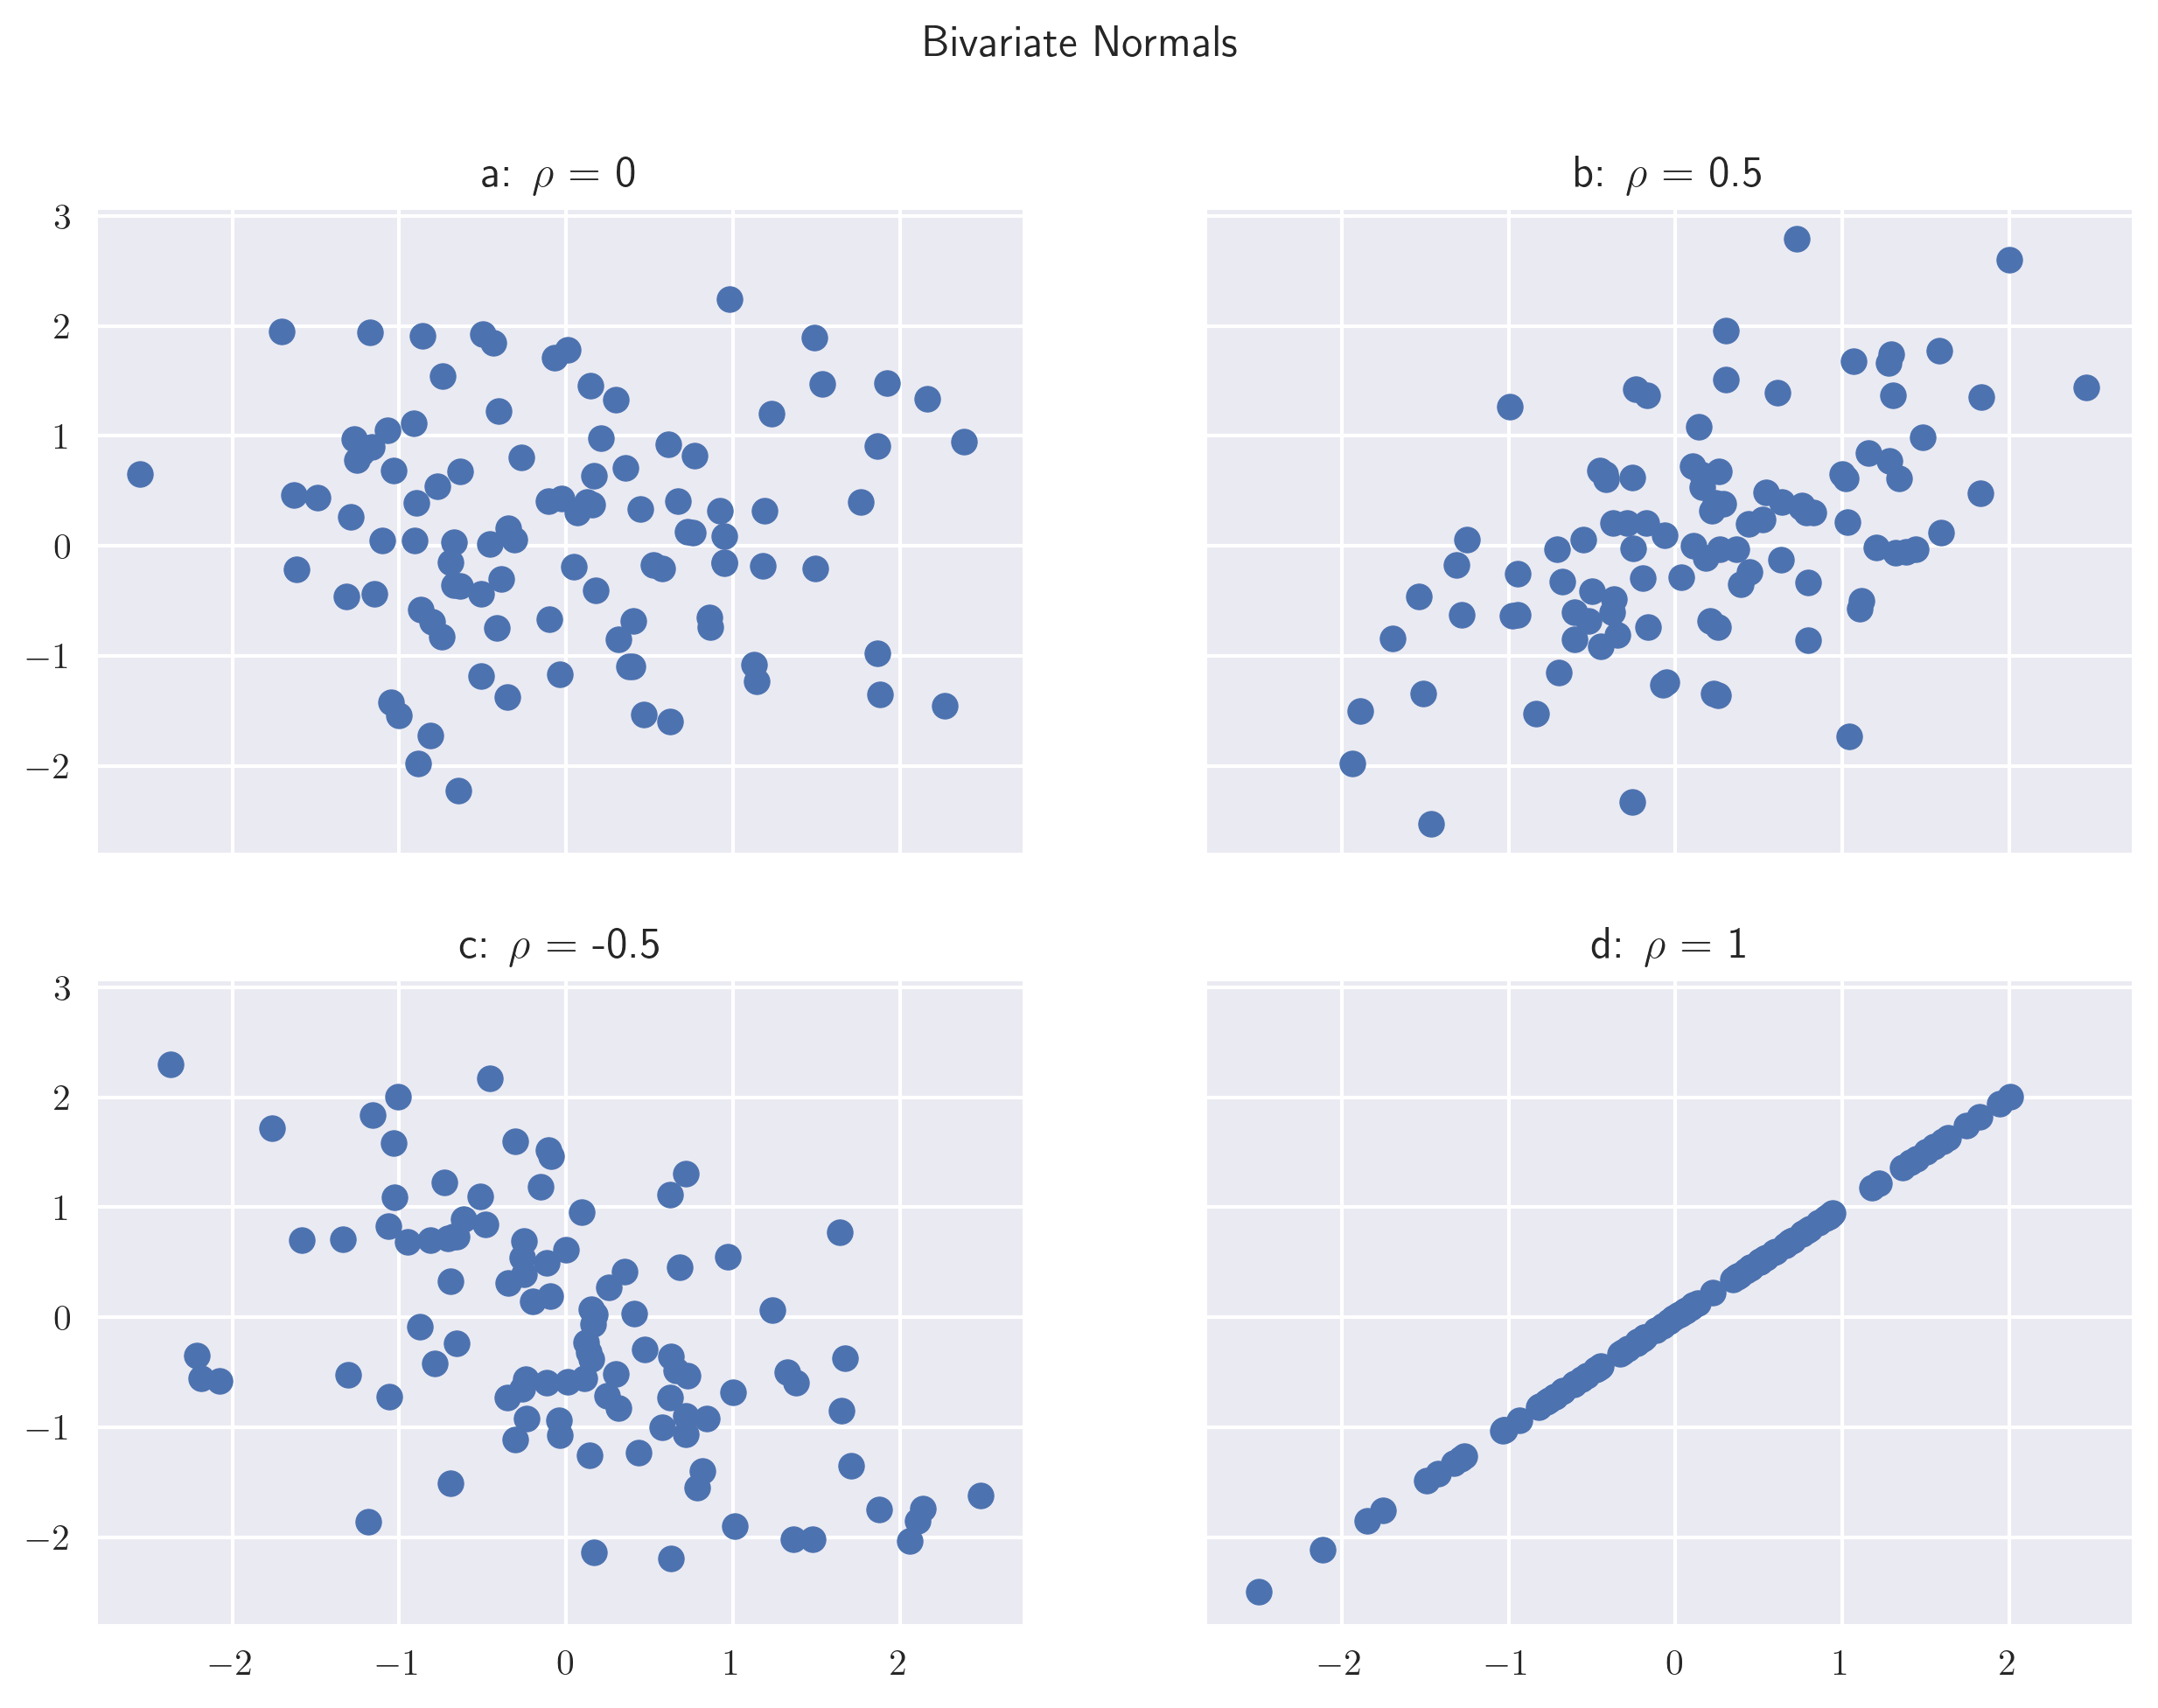

In [6]:
# Import modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Use LaTeX and increase resolution
plt.rcParams['text.usetex'],  plt.rcParams['figure.dpi'] = True, 300

# Use Seaborn style
plt.style.use('seaborn-v0_8')

# Set random seed
np.random.seed(0)

# Create list for problem parts
parts = ['a', 'b', 'c', 'd']

# Create list of covariance matrices
covs = [np.array([[1, 0], [0, 1]]), 
        np.array([[1, 0.5], [0.5, 1]]), 
        np.array([[1, -0.5], [-0.5, 1]]), 
        np.array([[1, 1], [1, 1]])]

# Set up subplots
fig, ax = plt.subplots(2, 2, sharex = True, sharey = True, 
                       figsize = (10, 7))

# Loop over titles and covariance matrices 
for i, part, cov in zip(range(4), parts, covs):
    
    # Get the row and column
    row, col = i // 2, i %2

    # Generate values
    vals = multivariate_normal.rvs(mean = np.zeros(2), 
                                   cov = cov, size = 100)
    
    # Get x- and y-coordinates
    x, y = zip(*vals)
    
    # Plot the values
    ax[row, col].scatter(x, y)
    
    # Get title
    title = part + r': $\rho$ = ' + str(cov[0, 1])
    
    # Give the plot a title
    ax[row, col].title.set_text(title)

# Give entire figure title
fig.suptitle('Bivariate Normals')

# Save the figure
plt.savefig(path + r'ex4-1.png')

plt.show()

In [8]:
# Import modules
import pandas as pd

# Load in data; make date the index
data = pd.read_csv(data_path, index_col = 'Date')

# Get covariance matrix
S = data.cov()

S

,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,WTW,WY,WYNN,XEL,XOM,XYL,YUM,ZBH,ZBRA,ZTS
A,0.000358,0.000202,0.000109,0.000172,0.000156,0.000202,0.000229,0.000254,0.000133,0.000171,...,0.000139,0.000241,0.000235,0.000109,0.000128,0.000211,0.000132,0.000155,0.000280,0.000207
AAPL,0.000202,0.000427,0.000100,0.000152,0.000161,0.000227,0.000311,0.000297,0.000130,0.000195,...,0.000156,0.000256,0.000267,0.000126,0.000134,0.000205,0.000148,0.000146,0.000299,0.000205
ABBV,0.000109,0.000100,0.000250,0.000116,0.000124,0.000107,0.000100,0.000110,0.000093,0.000117,...,0.000093,0.000139,0.000112,0.000092,0.000111,0.000099,0.000090,0.000111,0.000103,0.000118
ABT,0.000172,0.000152,0.000116,0.000270,0.000136,0.000157,0.000167,0.000162,0.000110,0.000155,...,0.000129,0.000187,0.000112,0.000131,0.000081,0.000154,0.000115,0.000140,0.000173,0.000171
ACGL,0.000156,0.000161,0.000124,0.000136,0.000449,0.000194,0.000148,0.000198,0.000201,0.000215,...,0.000194,0.000289,0.000299,0.000148,0.000225,0.000228,0.000174,0.000195,0.000205,0.000154
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XYL,0.000211,0.000205,0.000099,0.000154,0.000228,0.000213,0.000200,0.000267,0.000173,0.000208,...,0.000172,0.000298,0.000285,0.000138,0.000182,0.000382,0.000167,0.000185,0.000268,0.000178
YUM,0.000132,0.000148,0.000090,0.000115,0.000174,0.000153,0.000133,0.000175,0.000129,0.000152,...,0.000142,0.000232,0.000259,0.000113,0.000139,0.000167,0.000275,0.000167,0.000164,0.000150
ZBH,0.000155,0.000146,0.000111,0.000140,0.000195,0.000173,0.000139,0.000193,0.000150,0.000156,...,0.000142,0.000242,0.000316,0.000101,0.000182,0.000185,0.000167,0.000382,0.000194,0.000155
ZBRA,0.000280,0.000299,0.000103,0.000173,0.000205,0.000272,0.000313,0.000374,0.000175,0.000224,...,0.000168,0.000339,0.000356,0.000110,0.000189,0.000268,0.000164,0.000194,0.000675,0.000240


## Principal Component Analysis (PCA)

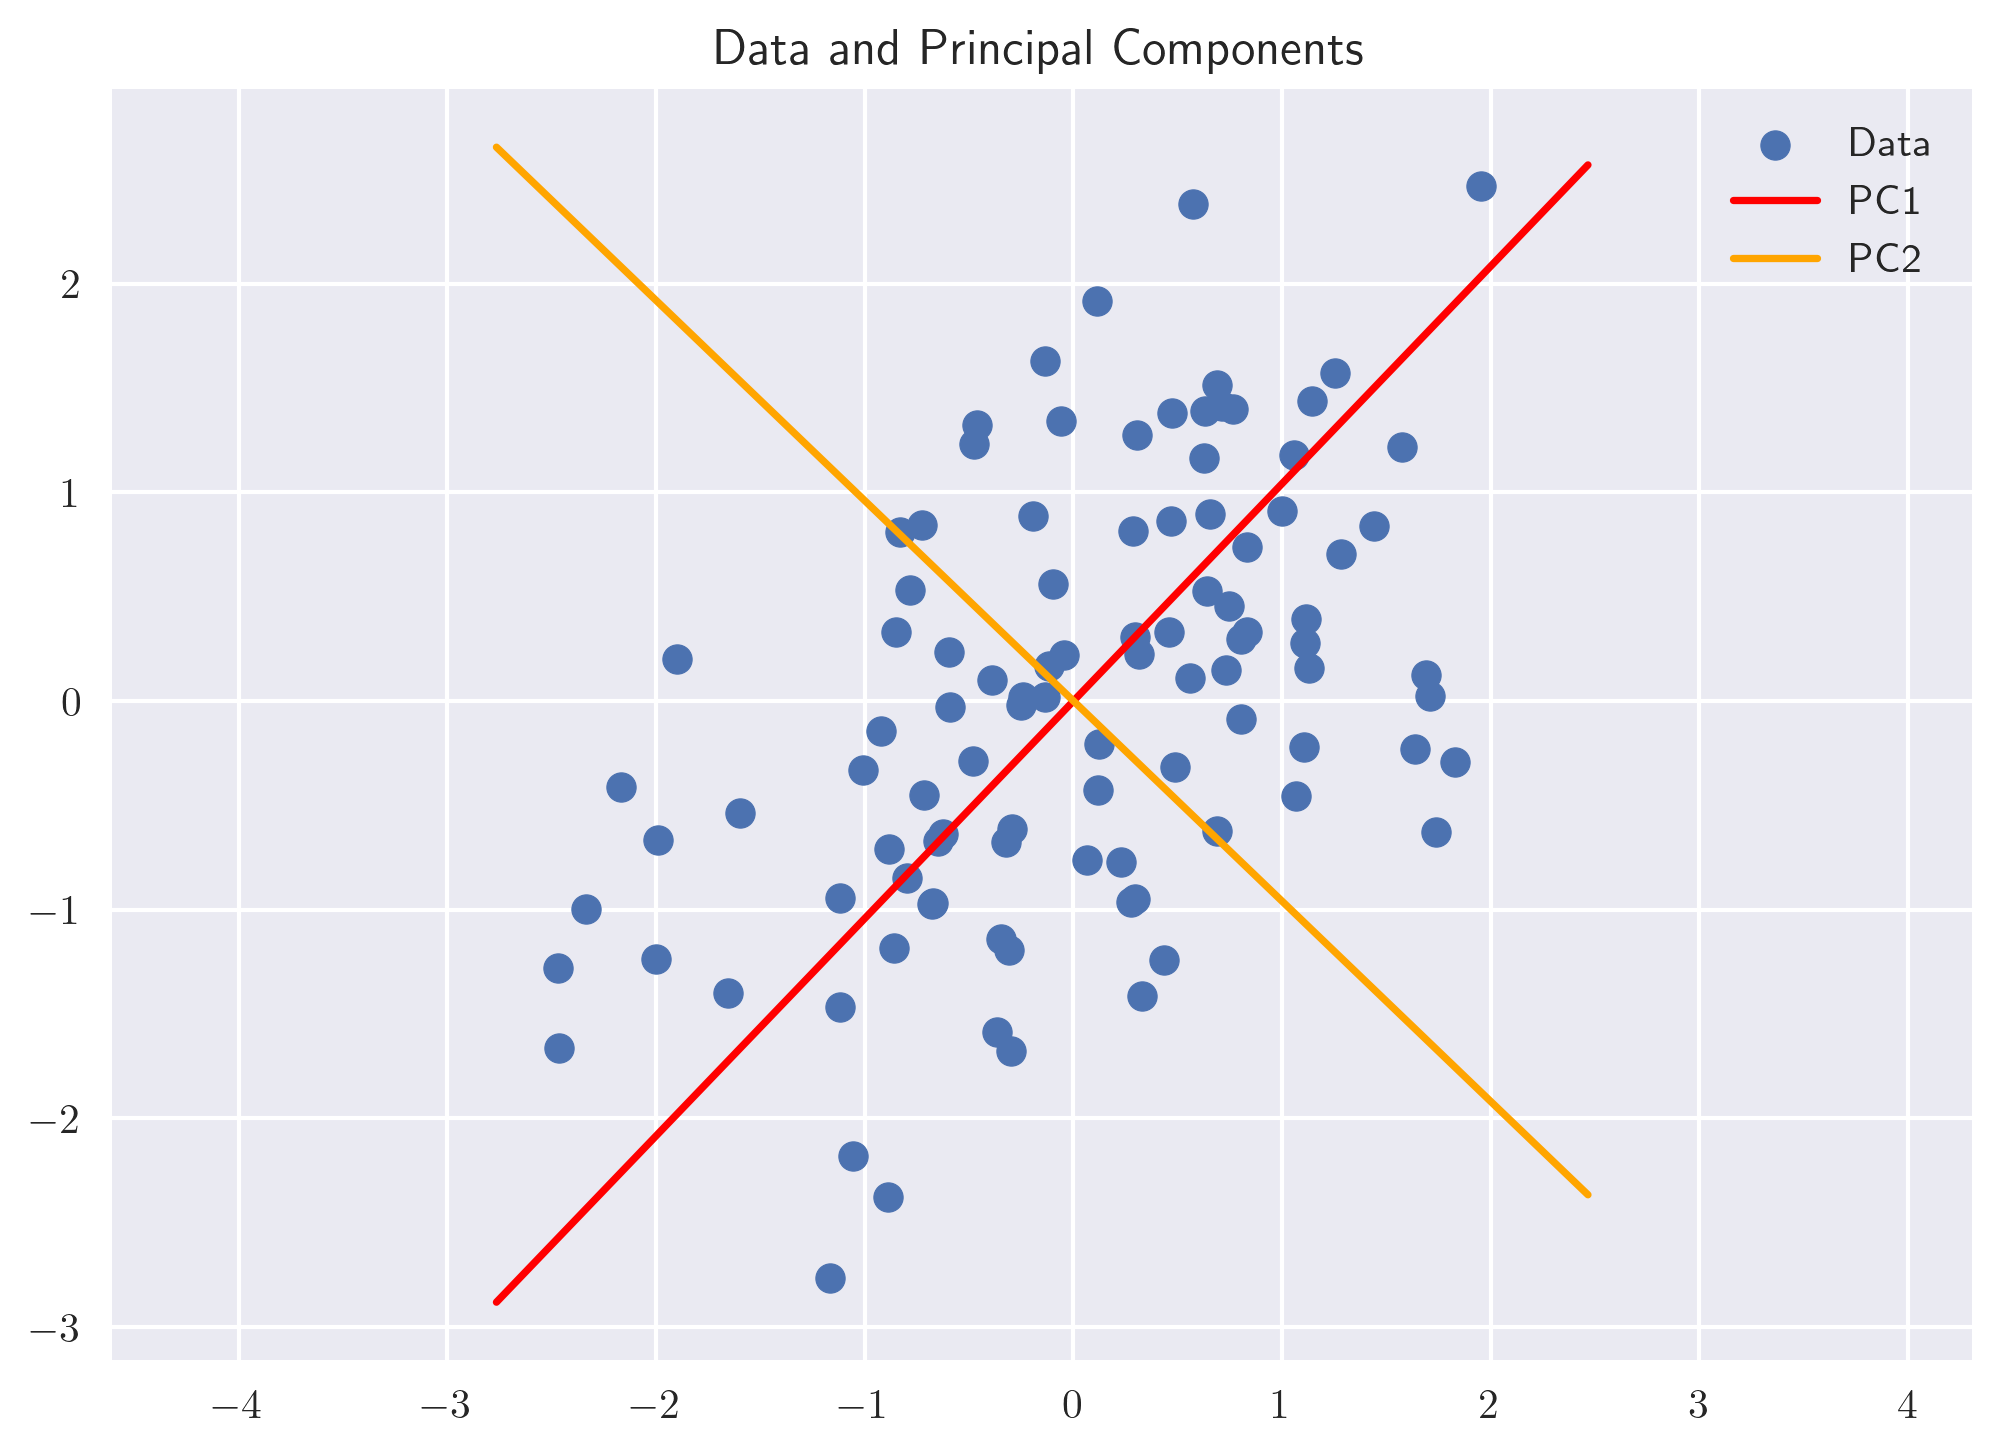

The product of the slopes of perpendicular lines is -1, and m_1 * m_2 = -1.0.


In [11]:
# Import modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Use Seaborn style
plt.style.use('seaborn-v0_8')

# Set random seed
np.random.seed(0)

# Get covariance matrix
cov = np.array([[1, 0.5], [0.5, 1]])

# Generate data
X = multivariate_normal.rvs(mean = np.zeros(2), 
                            cov = cov, size = 100)

# Demean data, though mean already close to zero
X -= X.mean(axis = 0)

# Calculate covariance matrix
S = np.cov(X, rowvar = False, ddof = 1)

# Get eigenvalues and eigenvectors
evals, evecs = np.linalg.eigh(S)

# Index to sort eigenvalues into descending order
idx = evals.argsort()[::-1]

# Sort eigenvalues and -vectors
evals, evecs = evals[idx], evecs[:, idx]

# Get slopes
m_1, m_2 = evecs[1, 0]/evecs[0, 0], evecs[1, 1]/evecs[0, 1]

# Get x-values for plot
x_vals = np.linspace(X.min(), X.max())

# Plot graph
plt.scatter(*X.T, label = 'Data')
plt.plot(x_vals, m_1 * x_vals, color = 'red', label = 'PC1')
plt.plot(x_vals, m_2 * x_vals, color = 'orange', label = 'PC2')

# Add legend
plt.legend()

# Make aspect ratio the same, so PC's look perp
plt.axis('equal')

# Add title
plt.title('Data and Principal Components')

# Save the figure
plt.savefig(path + r'ex4-2.png')

plt.show()

# Check to make sure lines perpendicular
print(f'The product of the slopes of perpendicular lines is -1, and m_1 * m_2 = {m_1 * m_2}.')

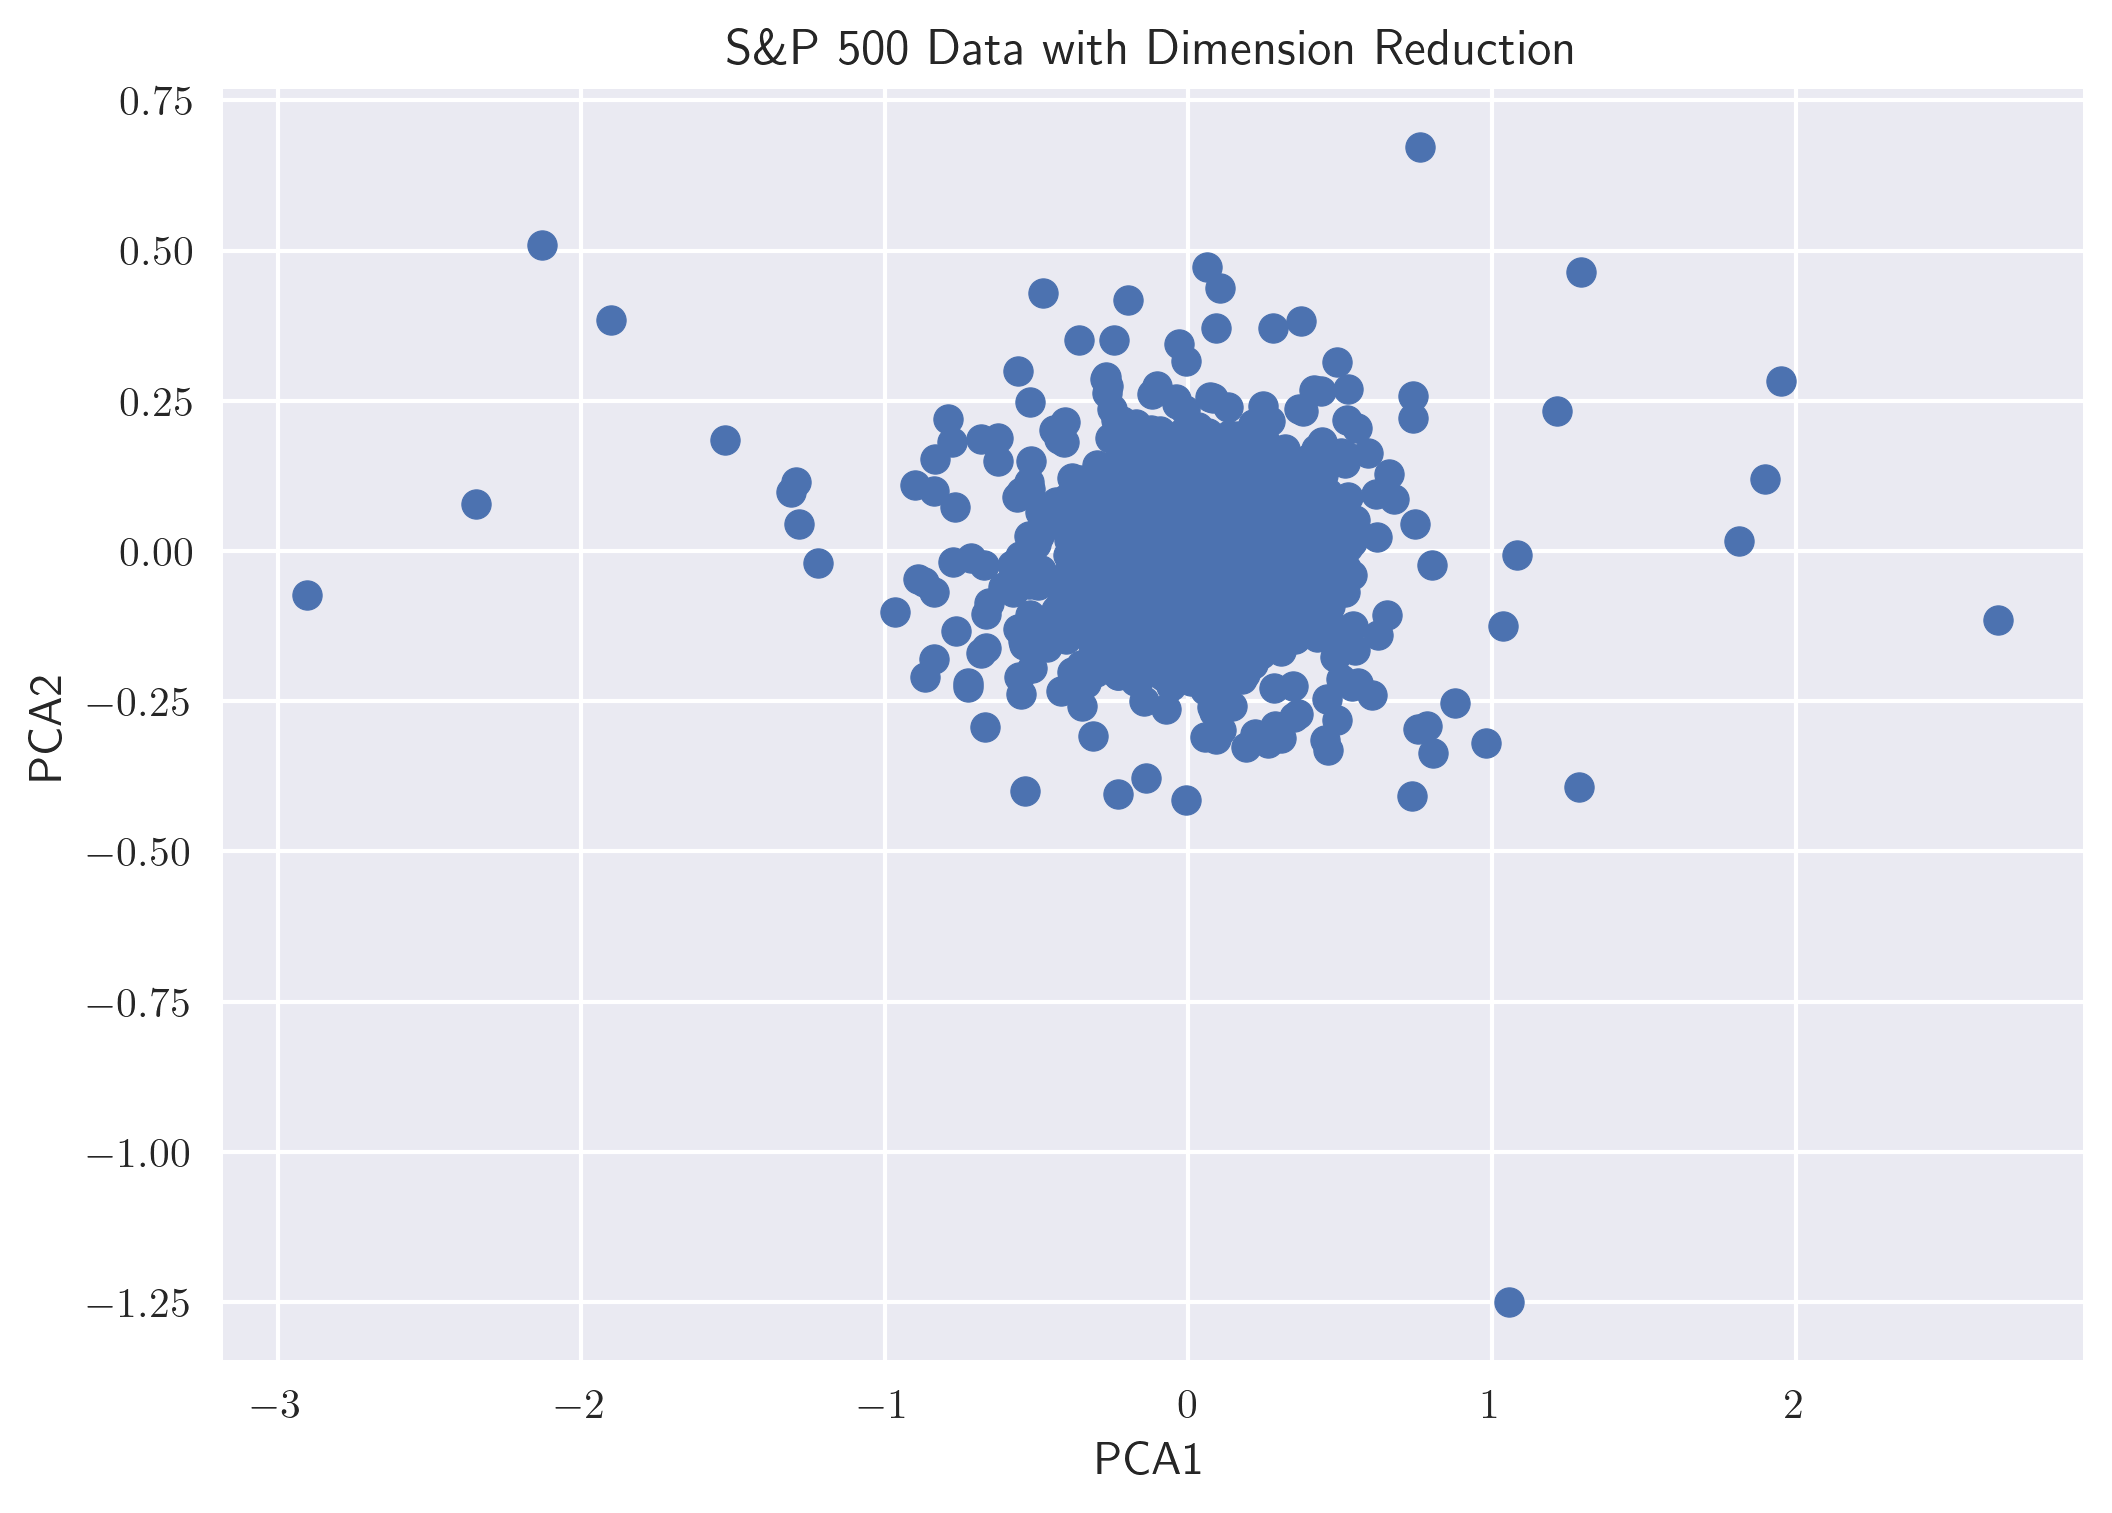

In [226]:
# Import modules
import numpy as np
import matplotlib.pyplot as plt

# Increase resolution
plt.rcParams['figure.dpi'] = 300

# Use Seaborn style
plt.style.use('seaborn-v0_8')

# Get S&P 500 return cov matrix
S = data.cov()

# Get the eigenvalues and eigenvectors
evals, evecs = np.linalg.eigh(S)

# Index to sort eigenvalues into descending order
idx = evals.argsort()[::-1]

# Change order
evals, evecs = evals[idx], evecs[:, idx]

# Convert the observations to a numpy array
X = data.values

# Demean X
X -= X.mean(axis = 0)

# Calculate loadings using the dot product
loadings = X @ evecs[:, 0:2]

# Unpack results
x, y = zip(*loadings)

# Get scatter plot
plt.scatter(x, y)

# Create x- and y-labels
plt.xlabel('PCA1')
plt.ylabel('PCA2')

# Give the plot a title
plt.title(r'S\&P 500 Data with Dimension Reduction')

# Save the figure
plt.savefig(path + r'ex4-3.png')

plt.show()


## Clipping Covariance Matrices

In [13]:
# Import modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Set the random seed
np.random.seed(0)

# Generate normal random variables
X = norm.rvs(size = (50, 100))

# Get the covariance matrix
S = np.cov(X, rowvar = False, ddof = 1)

# Get the eigenvalues
evals, _ =  np.linalg.eigh(S)

print(f'The sample covariance matrix has {np.sum(np.isclose(evals, 0))}',
      r'eigenvalues numerically indistinguishable from 0.')

The sample covariance matrix has 51 eigenvalues numerically indistinguishable from 0.


In [15]:
# Get the standard deviations
stds = np.sqrt(np.diag(S))

# Get the correlation matrix
C = np.diag(1/stds) @ S @ np.diag(1/stds)

# Get the eigenvalues and vectors of C
evals_c, evecs_c = np.linalg.eigh(C)

# Let lam_min be a small positive number outside of np.isclose threshold
lam_min = 1e-7

# Replace eigenvalues that are too small
evals_c[evals_c < lam_min] = lam_min

# Reconstruct correlation matrix
C_new = evecs_c @ np.diag(evals_c) @ evecs_c.T

# Make sure still correlation matrix
C_new = (np.diag(np.sqrt(1/np.diag(C_new))) @ C_new
            @ np.diag(np.sqrt(1/np.diag(C_new))))

# Multiply by standard deviations to make it a covariance matrix
S_new = np.diag(stds) @ C_new @ np.diag(stds)

# Get the eigenvalues
evals_new, _ =  np.linalg.eigh(S_new)

print(f'The new covariance matrix has {np.sum(np.isclose(evals_new, 0))}',
      r'eigenvalues numerically indistinguishable from 0.')

The new covariance matrix has 0 eigenvalues numerically indistinguishable from 0.


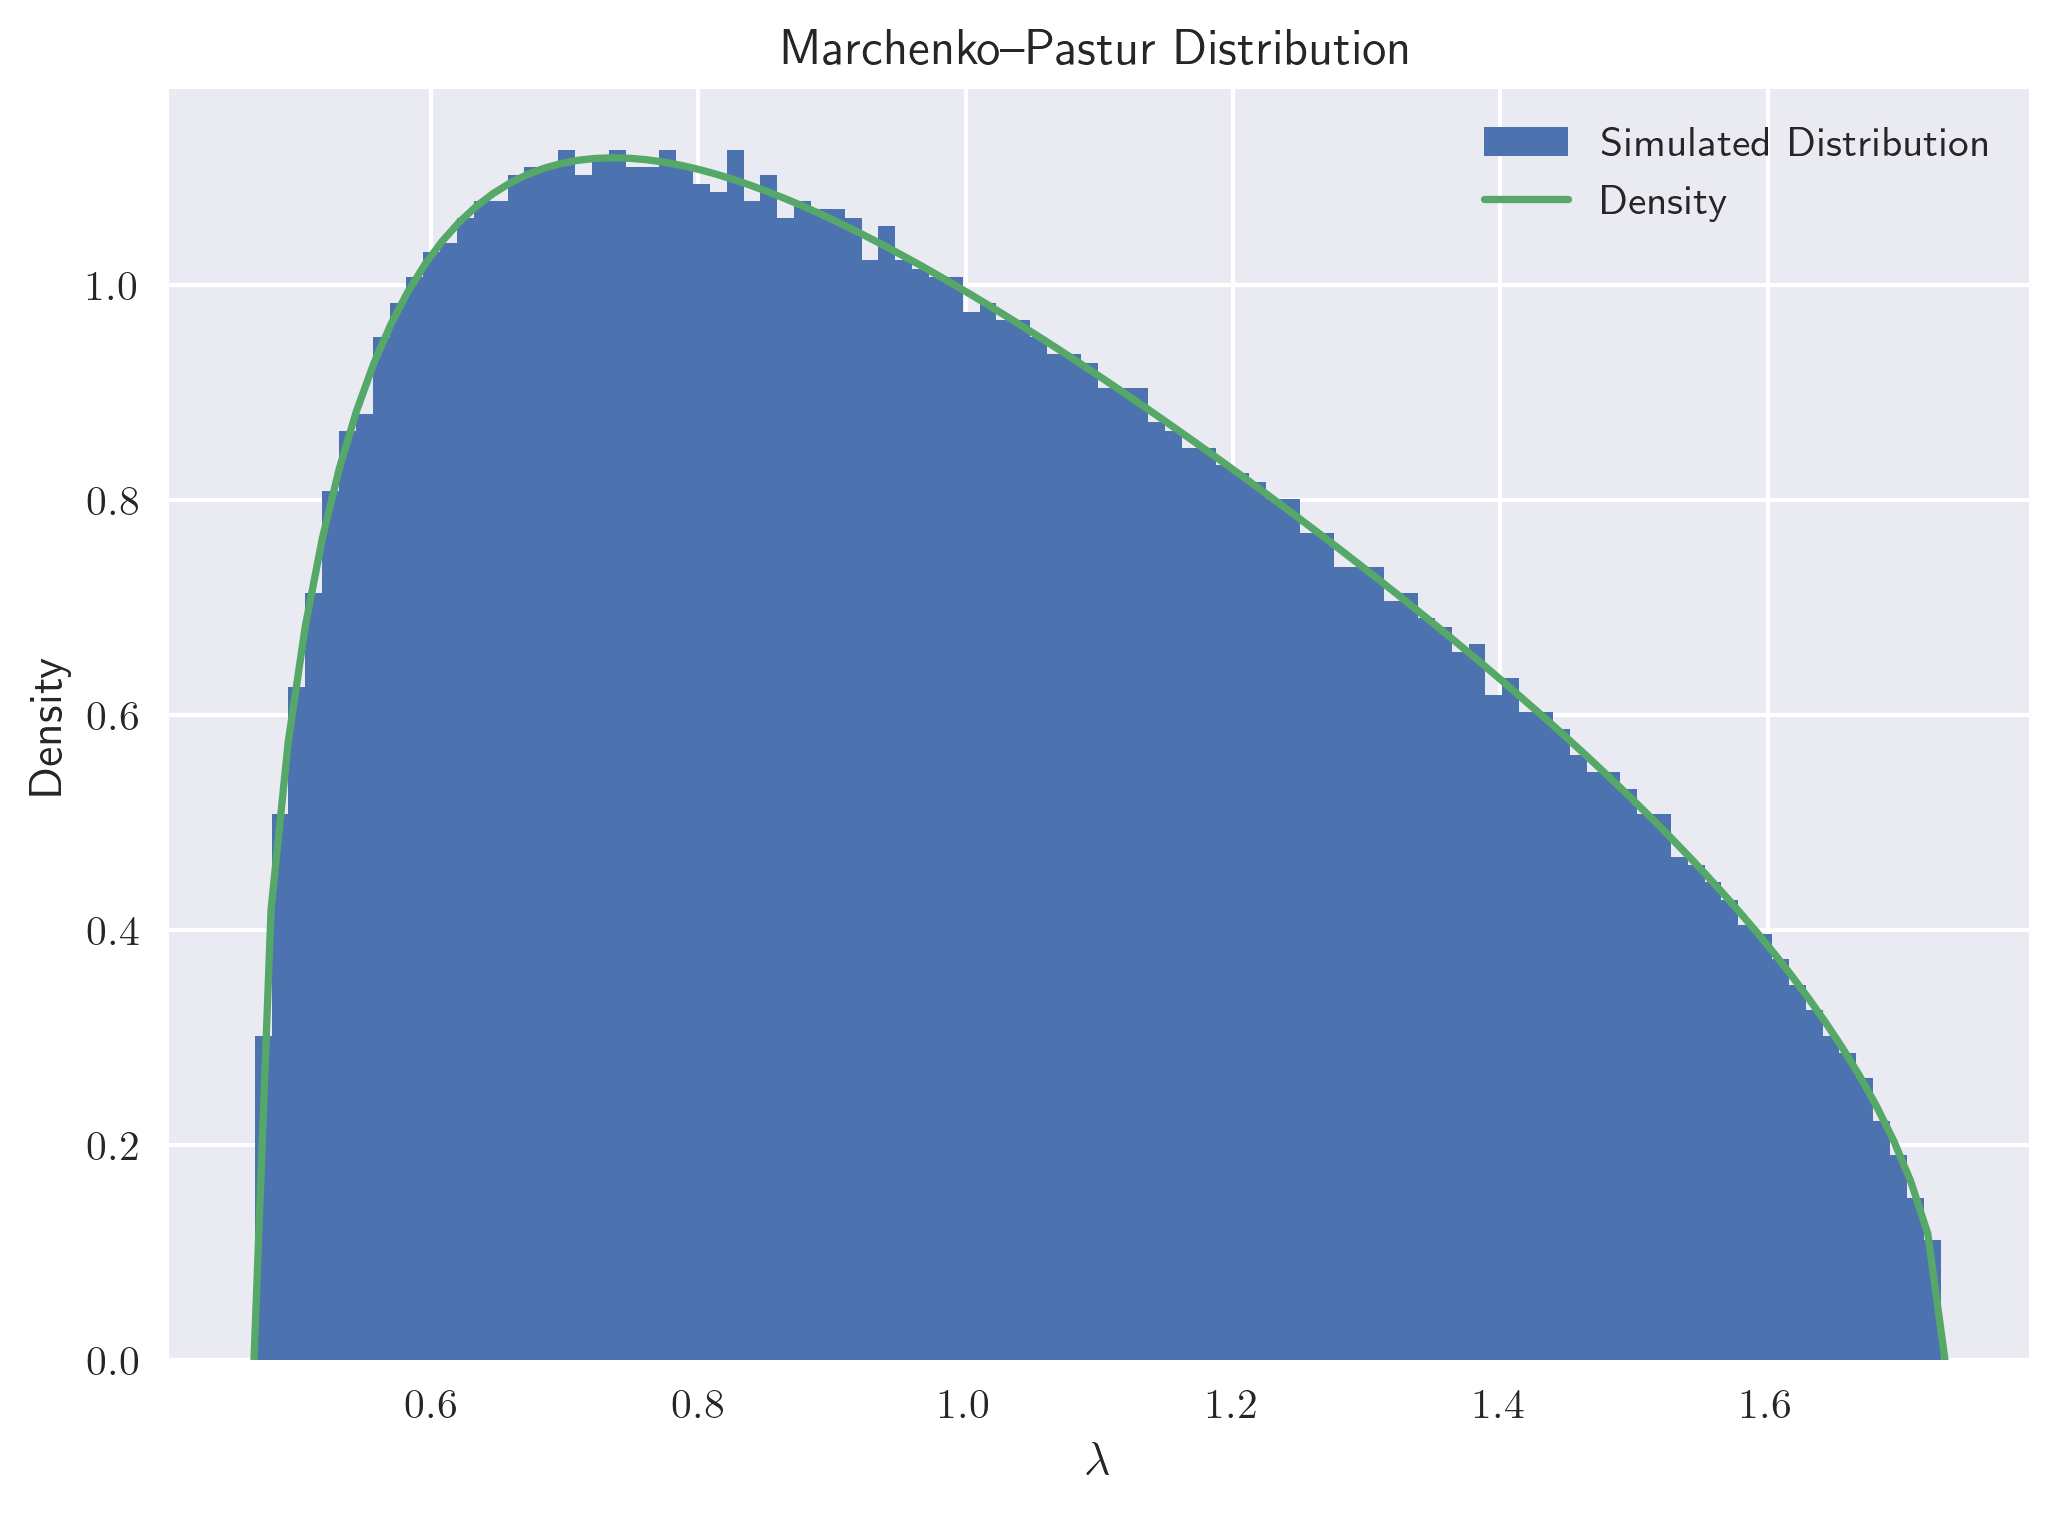

This script took 1.42 minutes to run.


In [17]:
# Import modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import time

# Use LaTeX and increase resolution
plt.rcParams['text.usetex'],  plt.rcParams['figure.dpi'] = True, 300

# Use Seaborn style
plt.style.use('seaborn-v0_8')

# Set the random seed
np.random.seed(0)

# Start the clock
start_time = time.perf_counter()

# Generate normal random variables
X = norm.rvs(size = (100_000, 10_000))

# Get the number of observations and variables
T, N = X.shape

# Get correlation matrix
C = np.corrcoef(X, rowvar = False)

# q is the number of observations divided by the number of variables
q = T/N

# Get eigenvalues
evals, _ = np.linalg.eigh(C)

# Get support of Marchenko–Pastur distribution
lam_minus, lam_plus = (1 - np.sqrt(1/q))**2, (1 + np.sqrt(1/q))**2 
        
# Define pdf
def f(lam):
    
    # Support of Marchenko–Pastur distribution
    if lam_minus <= lam <= lam_plus:
    
        return q/(2 * np.pi) * np.sqrt((lam_plus - lam) * (lam - lam_minus))/lam
                
    else:
        
        return 0

# Get lam_vals
lam_vals = np.linspace(lam_minus, lam_plus, 100)

# Get density values
f_vals = [f(lam) for lam in lam_vals]

# Plot histogram
plt.hist(evals, density = True, bins = int(np.sqrt(N)), label = 'Simulated Distribution')

# Plot density
plt.plot(lam_vals, f_vals, label = 'Density')

# Add legend
plt.legend()

# Add x-label
plt.xlabel(r'$\lambda$')

# Add y-label
plt.ylabel(r'Density')

# Add title to plot
plt.title(r'Marchenko–Pastur Distribution')

# Save the figure
plt.savefig(path + r'ex4-4.png')

plt.show()

print(f'This script took {(time.perf_counter() - start_time)/60:.2f} minutes to run.')

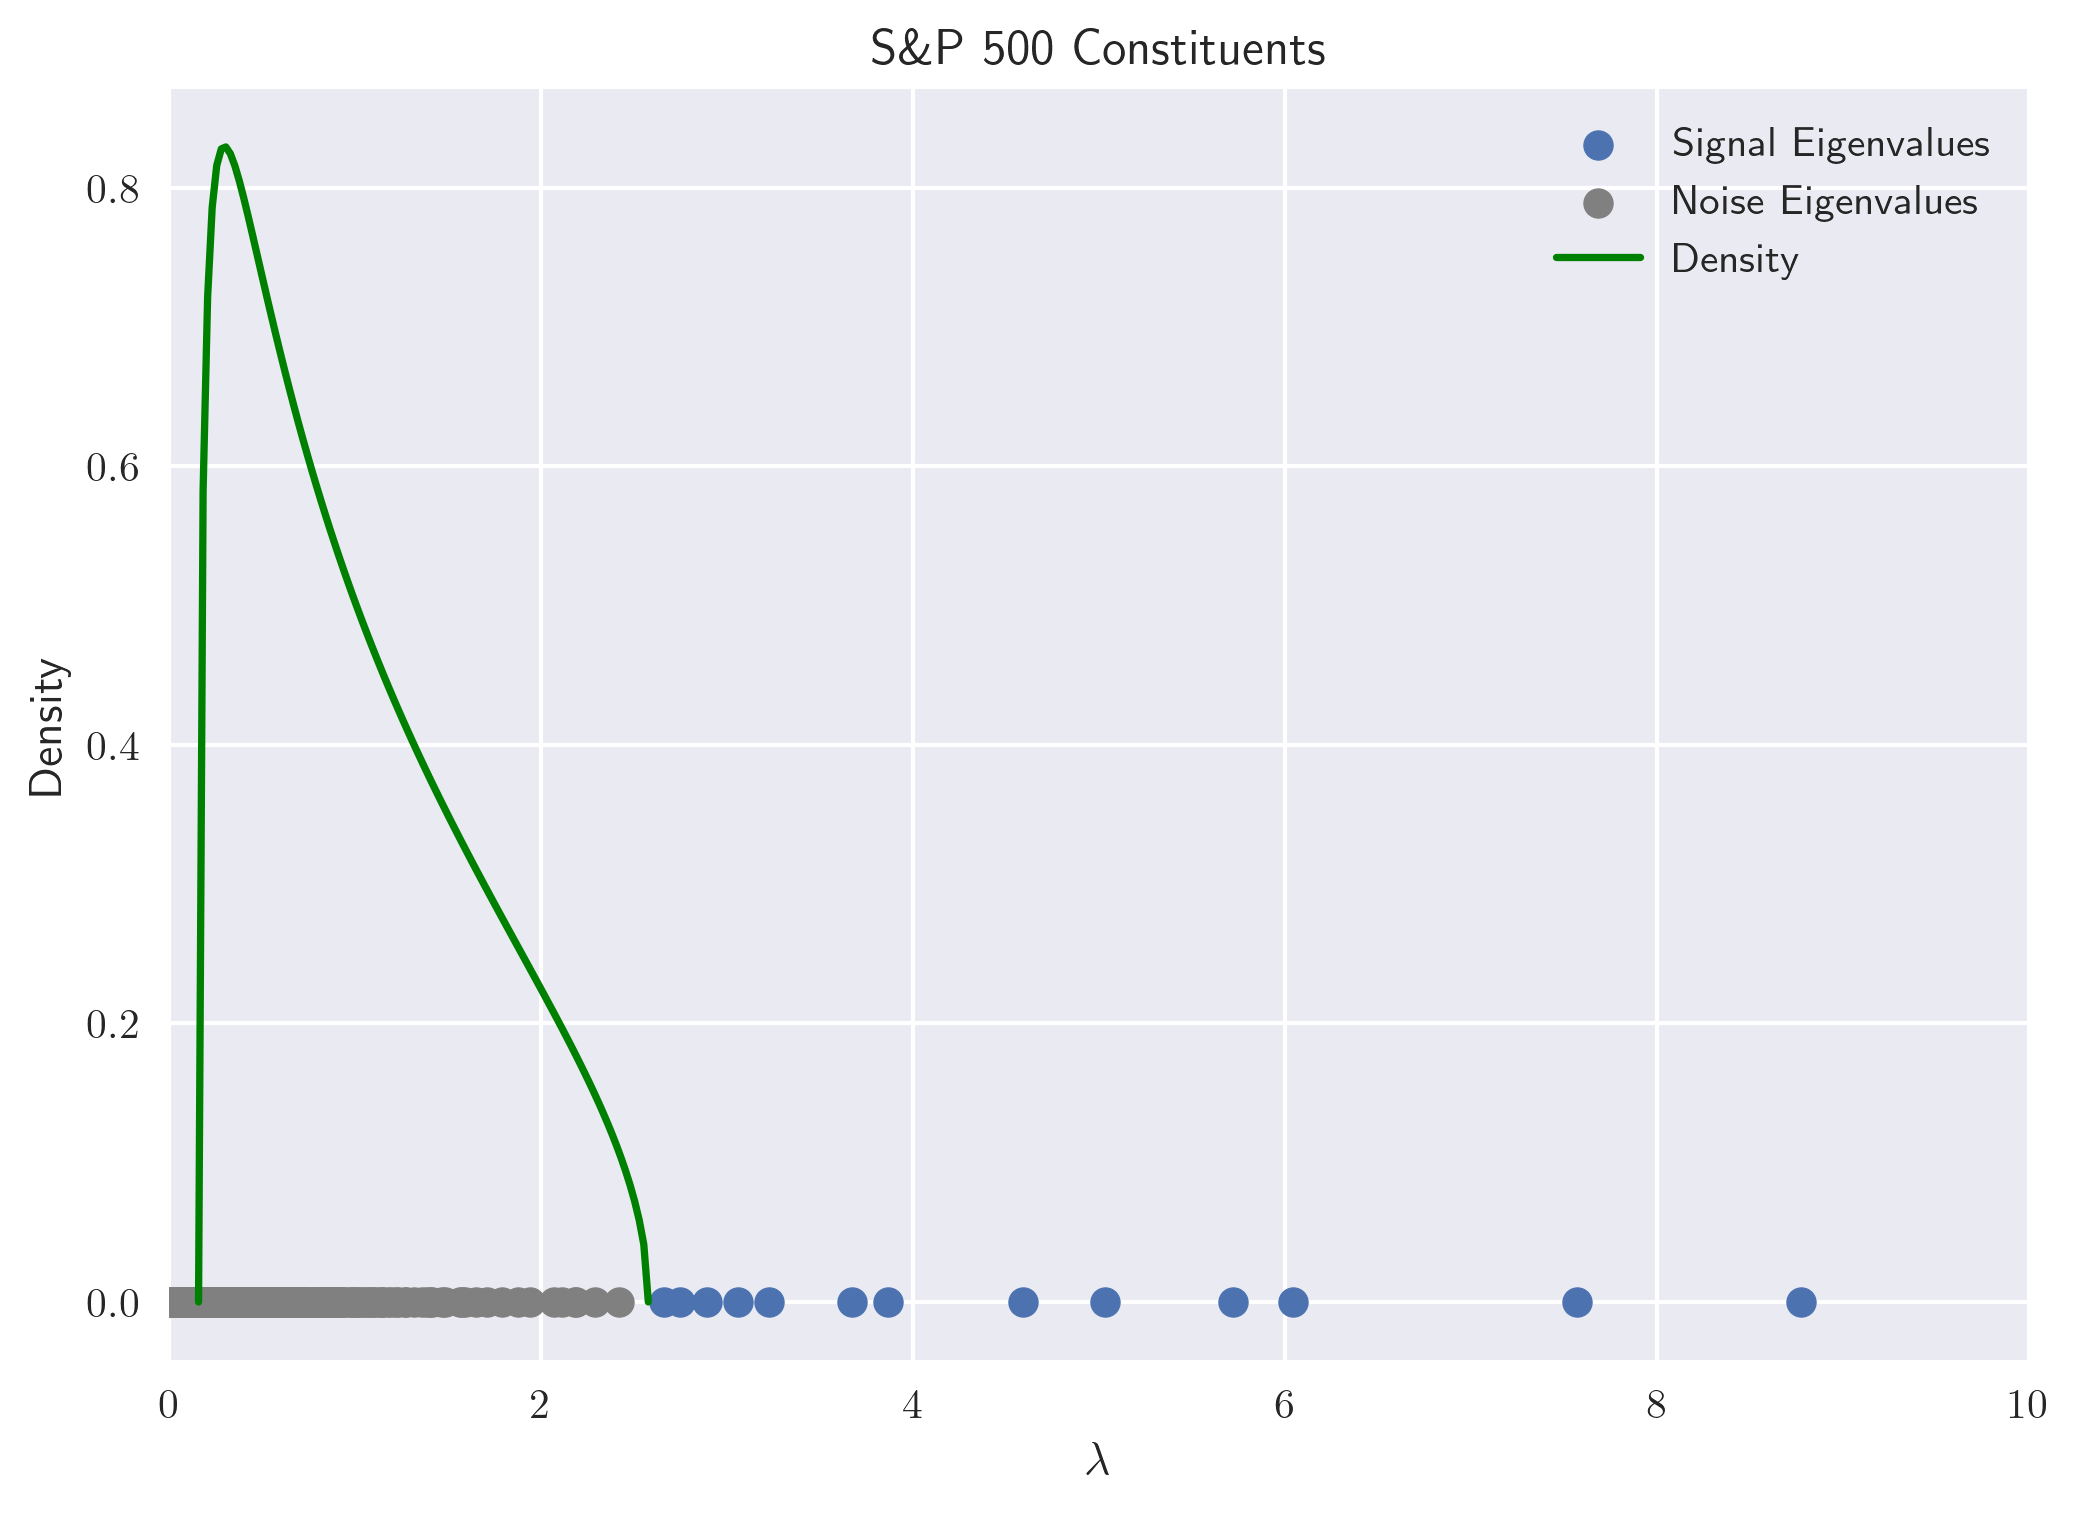

In [18]:
# Import modules
import pandas as pd

# Load in data
data = pd.read_csv(data_path, index_col = 'Date')

# Get covariance matrix; convert to numpy array
S = data.cov().values

# Get the standard deviations
stds = np.sqrt(np.diag(S))

# Calculate correlation matrix
C = np.diag(1/stds) @ S @ np.diag(1/stds)

# Get the eigenvalues and vectors
evals, evecs =  np.linalg.eigh(C)

# Save q
q = data.shape[0]/data.shape[1]

# Get support of Marchenko–Pastur distribution
lam_minus, lam_plus = (1 - np.sqrt(1/q))**2, (1 + np.sqrt(1/q))**2 
        
# Define pdf
def f(lam):
    
    # Suppose of Marchenko–Pastur distribution
    if lam_minus <= lam <= lam_plus:
    
        return q/(2 * np.pi) * np.sqrt((lam_plus - lam) * (lam - lam_minus))/lam
                
    else:
        
        return 0
    
# Get lam_vals
lam_vals = np.linspace(lam_minus, lam_plus, 100)

# Get density values
f_vals = [f(lam) for lam in lam_vals]

# Plot eigenvalues that are signal
plt.scatter(evals[evals > lam_plus], np.zeros(np.sum(evals > lam_plus)), 
            label = 'Signal Eigenvalues')

# Plot eigenvalues that are noise
plt.scatter(evals[evals <= lam_plus], np.zeros(np.sum(evals <= lam_plus)), 
            label = 'Noise Eigenvalues', color = 'gray')

# Plot density
plt.plot(lam_vals, f_vals, label = 'Density', color = 'green')

# There are 3 eigenvalues much larger than 10
plt.xlim([0, 10])

# Add legend
plt.legend()

# Add x-label
plt.xlabel(r'$\lambda$')

# Add y-label
plt.ylabel(r'Density')

# Add title to plot
plt.title(r'S\&P 500 Constituents')

# Save the figure
plt.savefig(path + r'ex4-5.png')

plt.show()

In [19]:
# Import copy
import copy

# Initialize new eigenvalues
evals_new = copy.deepcopy(evals)

# Replace noise eigenvalues with mean
evals_new[evals_new < lam_plus] = np.mean(evals_new[evals_new < lam_plus])

# Construct new correlation matrix
C_new = evecs @ np.diag(evals_new) @ evecs.T

# Make sure still correlation matrix
C_new = np.diag(1/np.sqrt(np.diag(C_new))) @ C_new @ np.diag(1/np.sqrt(np.diag(C_new)))

# Make new covariance matrix
S_new = np.diag(stds) @ C_new @ np.diag(stds)

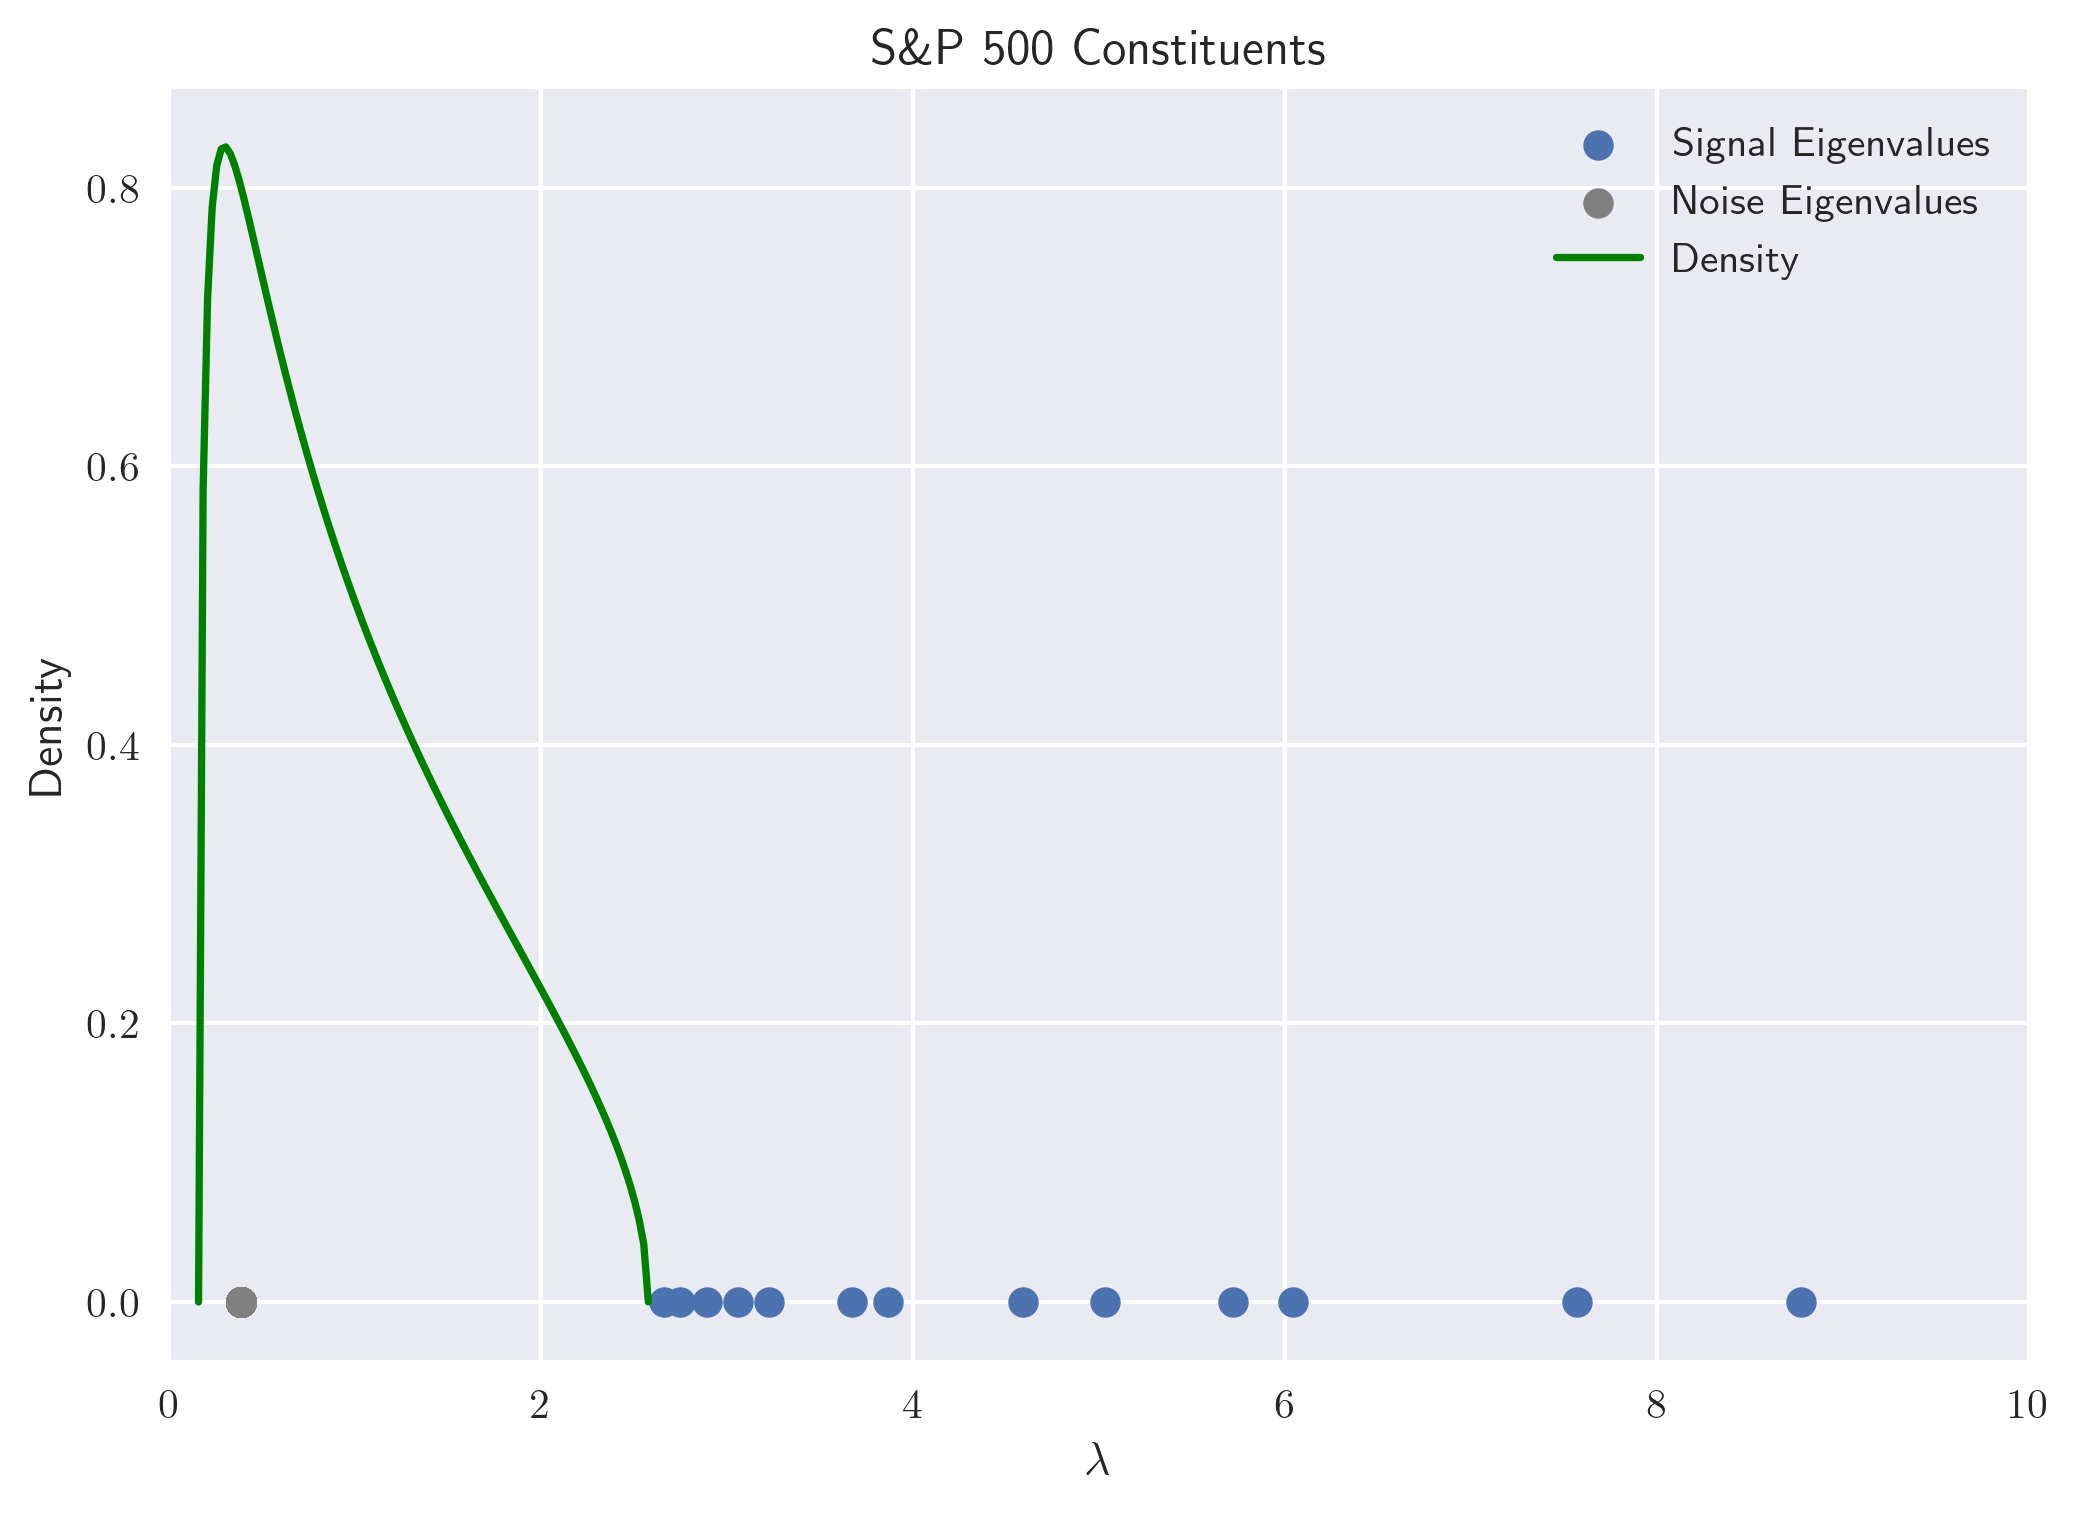

In [25]:
# Plot eigenvalues that are signal
plt.scatter(evals_new[evals_new > lam_plus], np.zeros(np.sum(evals_new > lam_plus)), 
            label = 'Signal Eigenvalues')

# Plot eigenvalues that are noise
plt.scatter(evals_new[evals_new <= lam_plus], np.zeros(np.sum(evals_new <= lam_plus)), 
            label = 'Noise Eigenvalues', color = 'gray')

# Plot density
plt.plot(lam_vals, f_vals, label = 'Density', color = 'green')

# There are 3 eigenvalues much larger than 10
plt.xlim([0, 10])

# Add legend
plt.legend()

# Add x-label
plt.xlabel(r'$\lambda$')

# Add y-label
plt.ylabel(r'Density')

# Add title to plot
plt.title(r'S\&P 500 Constituents')

# Save the figure
plt.savefig(path + r'ex4-6.png')

plt.show()

## Stochastic Calculus

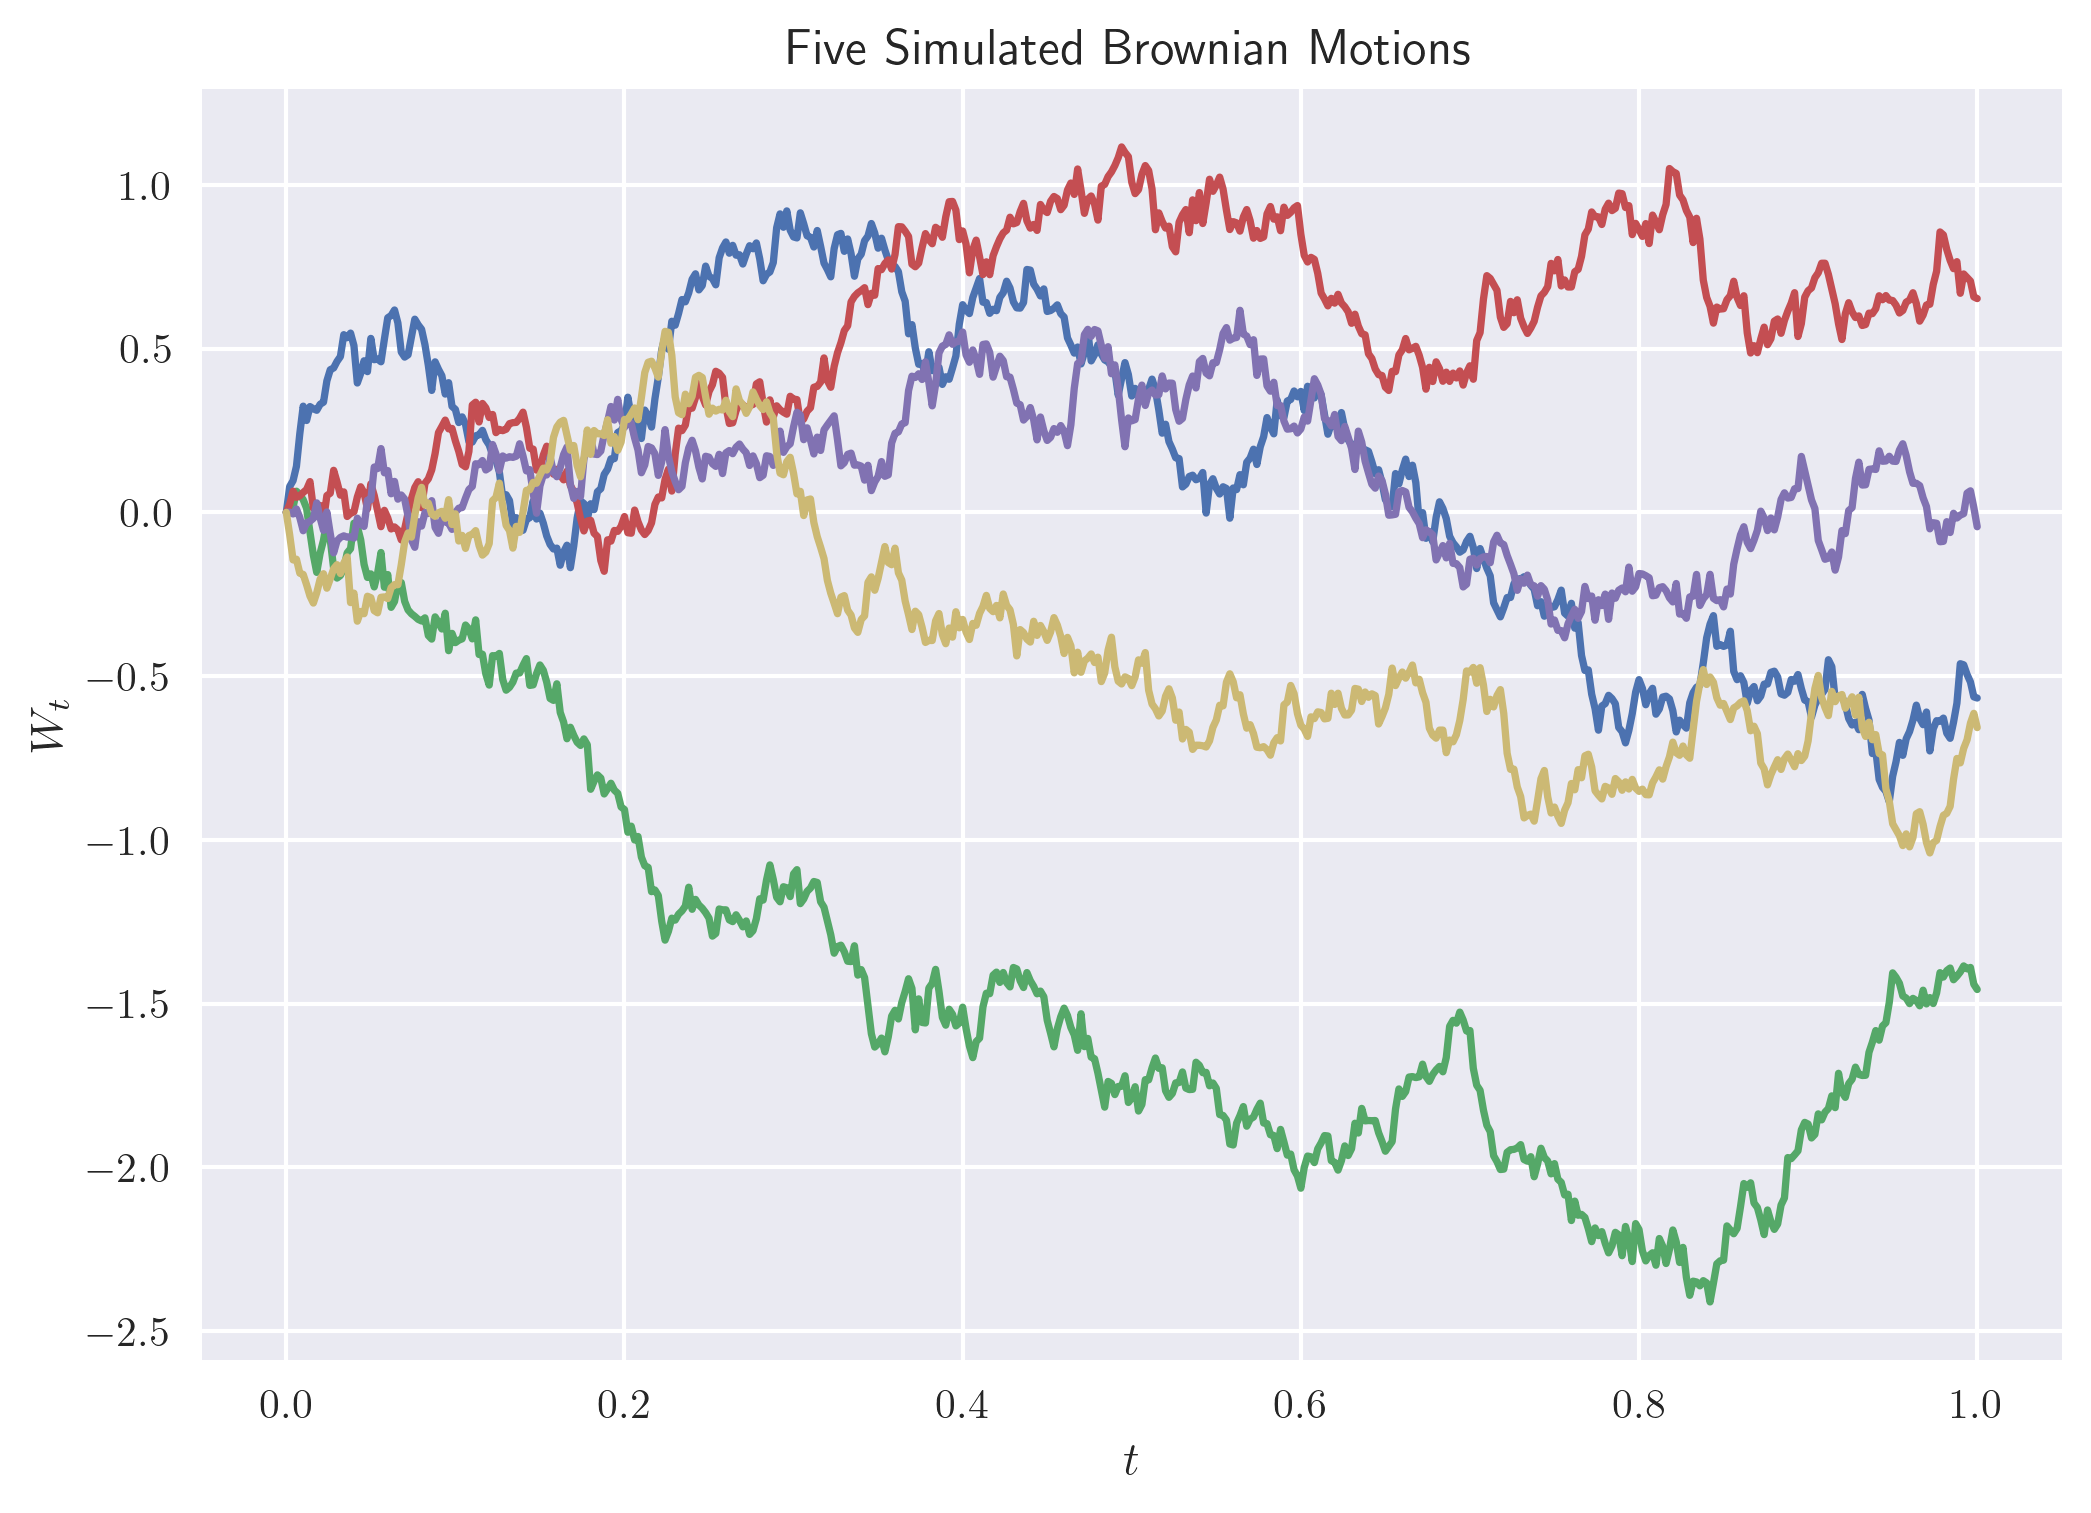

In [27]:
# Import modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Use LaTeX and increase resolution
plt.rcParams['text.usetex'],  plt.rcParams['figure.dpi'] = True, 300

# Use Seaborn style
plt.style.use('seaborn-v0_8')

# Set the random seed
np.random.seed(0)

# Break up so exact BM at n + 1 times
n = 500

# Simulate five Brownian motions
for _ in range(5):
    
    # Simulate Brownian motion for t in [0, 1]
    Z = norm.rvs(scale = np.sqrt(1/n), size = n)
    
    # Take the cumulative sum; add 0 for the t = 0 value
    W = np.insert(np.cumsum(Z), 0, 0)
    
    # Plot results
    plt.plot(np.linspace(0, 1, n + 1), W)
    
# Add x-label
plt.xlabel(r'$t$')

# Add y-label
plt.ylabel(r'$W_t$')

# Add title to plot
plt.title(r'Five Simulated Brownian Motions')

# Save the figure
plt.savefig(path + r'ex4-7.png')

plt.show()

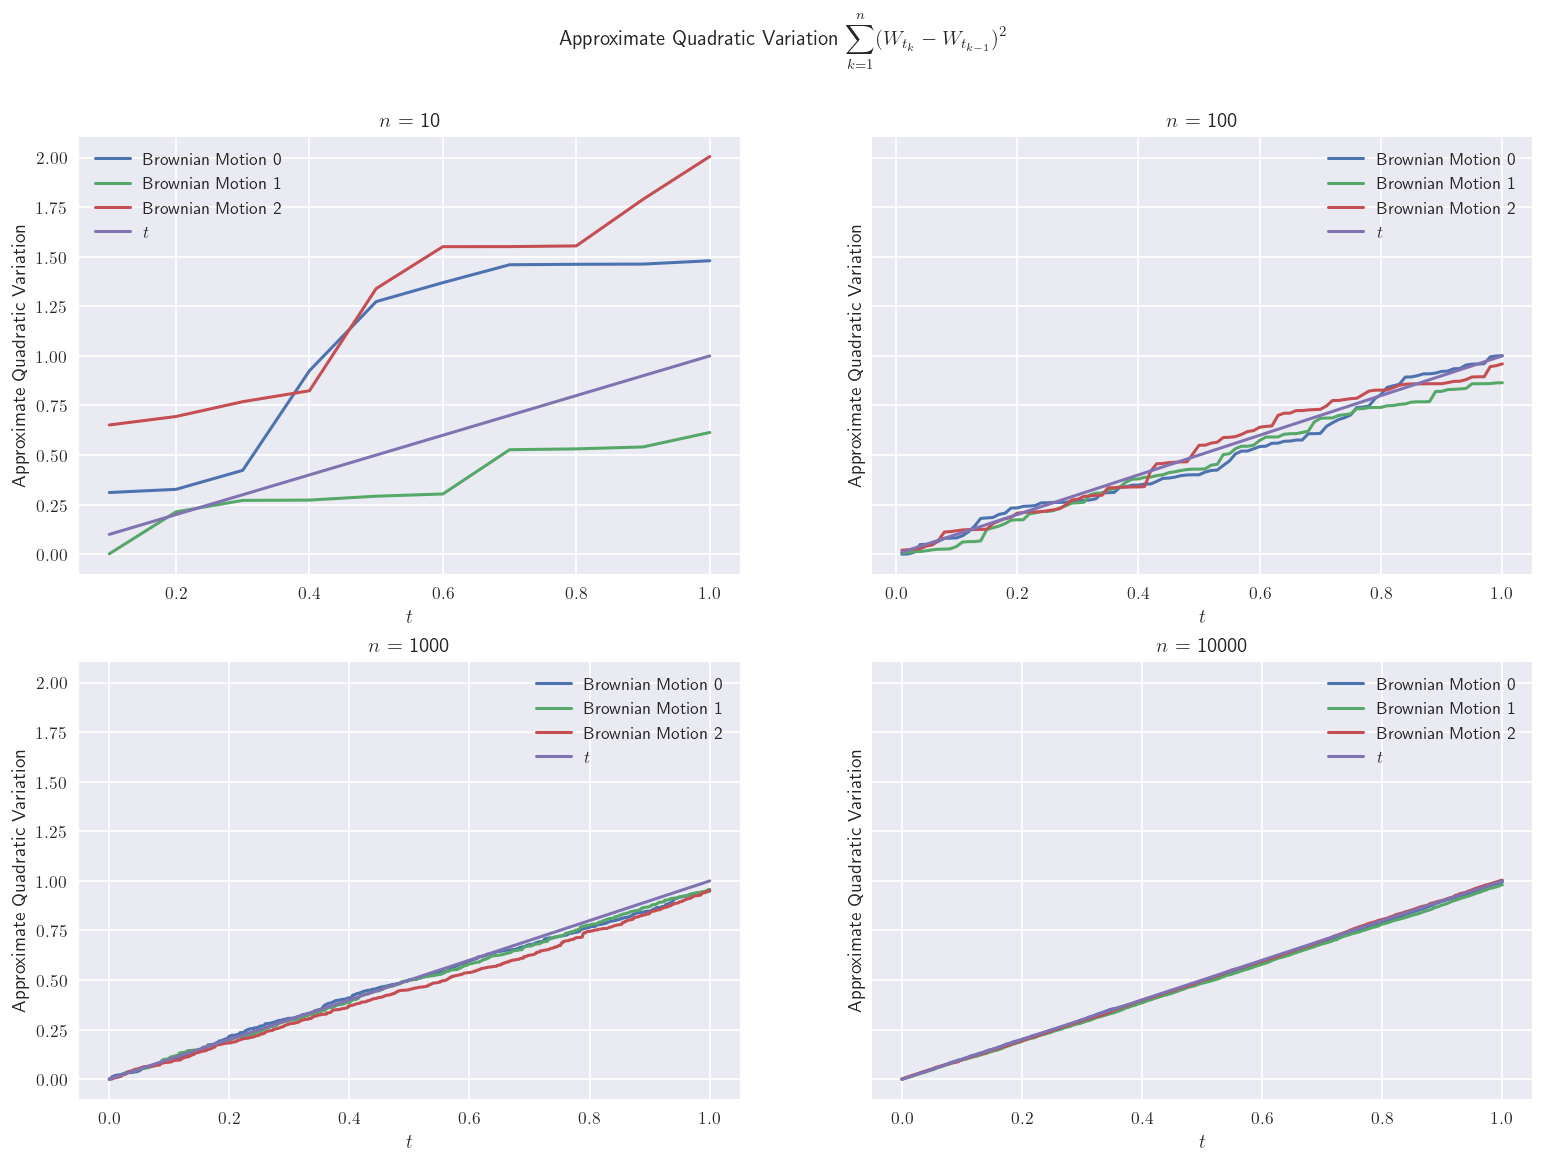

In [9]:
# Import modules
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import norm

# Use LaTeX and increase resolution
plt.rcParams['text.usetex'],  plt.rcParams['figure.dpi'] = True, 300

# Use Seaborn style
plt.style.use('seaborn-v0_8')

# Set the random seed
np.random.seed(0)

# Define n-values
n_vals = [10, 100, 1000, 10000]

# Set up subplots
fig, ax = plt.subplots(2, 2, sharey = True, figsize = (15, 10),
                      dpi = 125)

# Simulate five Brownian motions
for i, n in enumerate(n_vals):
    
    # Get row and column
    row, col = i//2, i % 2
    
    # Difference of two Brownian motions is normal
    dW = norm.rvs(scale = np.sqrt(1/n), size = (3, n))
    
    # Calculate quadratic variance
    quad_var = np.cumsum(dW**2, axis = 1)
    
    # Plot results
    for j in range(3):
        
        ax[row, col].plot(np.linspace(1/n, 1, n), quad_var[j, :], label = f'Brownian Motion {j}')

    # Plot t
    ax[row, col].plot(np.linspace(1/n, 1, n), np.linspace(1/n, 1, n), 
         label = r'$t$')
    
    # Add x-label
    ax[row, col].set_xlabel(r'$t$')

    # Add y-label
    ax[row, col].set_ylabel(r'Approximate Quadratic Variation')
    
    # Give plot a title
    ax[row, col].set_title(f'$n$ = {n}')
    
    # Add legend
    ax[row, col].legend()

# Add title to plot
plt.suptitle(r'Approximate Quadratic Variation $\displaystyle\sum_{k = 1}^{n} (W_{t_k} - W_{t_{k - 1}})^2$')

# Save the figure
plt.savefig(path + r'ex4-8.png')

plt.show()

In [53]:
# Import modules
import numpy as np
from scipy.stats import norm

# Set the random seed
np.random.seed(0)

# Set n, so there are n + 1 places where BM exact
n = 1_000_000

# Define T
T = 1

# Simulate independent increment
dW = norm.rvs(scale = np.sqrt(T/n), size = n)

# Sum up to get BM
W = np.insert(np.cumsum(dW), 0, 0)

# Approximate Ito integral; using left endpoints
integral_simulated = np.sum(W[0:-1] * dW)

# Write analytic result
integral_analytic = 1/2 * W[-1]**2 - T/2

print(f'The simulated result is {integral_simulated:.3f} while the analytic result is {integral_analytic:.3f}.')

The simulated result is 0.643 while the analytic result is 0.643.
